# M4 — Detector: out-of-distribution evaluation (notebook 05)

Tests the trained detector heads on **genuinely unseen data** — generators,
datasets, and wild images the heads never encountered during training.

**Two heads compared throughout:**
- `head.pt` — SDv1.4-only (run `cb68637`)
- `head_mixed.pt` — mixed-generator ablation (run `8cf8026_mixed`)

**Three test sources:**
1. **Synthbuster** — academic dataset (Zenodo), 9 generators × 1,000 images
   incl. DALL·E 2/3, Firefly, Midjourney v5 — genuinely zero-shot
2. **Wild uploads** — your own ChatGPT/Gemini/Firefly/phone images
3. **Transport resilience** — same 7 hops as M1/M2 matrices, now measuring
   whether the classifier score survives where metadata/watermarks died

Convention: commit WITH outputs — run record.

In [10]:
# ── Setup ──────────────────────────────────────────────────────
!apt-get -qq install -y libimage-exiftool-perl p7zip-full > /dev/null
!git clone -q https://github.com/Waranika/AI-image-Checkers.git 2>/dev/null || echo "already cloned"
%cd /content/AI-image-Checkers
%pip install -q -e .
import sys; sys.path.insert(0, "/content/AI-image-Checkers")

import json, shutil, torch
import numpy as np
from pathlib import Path
from PIL import Image

from google.colab import drive
drive.mount('/content/drive')

print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

/content/AI-image-Checkers
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ai-image-id (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
torch: 2.11.0+cu128 | cuda: True


## Load both heads from Drive

In [11]:
from training.train_head import build_head, _load_split, _batched_logits

def load_head(ckpt_path, cal_path, device="cuda"):
    """Load a trained head + its calibration temperature. Returns (head, T)."""
    state = torch.load(ckpt_path, map_location="cpu")
    head = build_head(state["dim"])
    head.load_state_dict(state["state_dict"])
    head = head.to(device).eval()
    T = json.load(open(cal_path))["temperature"]
    print(f"loaded {Path(ckpt_path).name}: dim={state['dim']}, T={T:.3f}")
    return head, T

# Adjust these paths if your run hashes differ
RUNS = Path("/content/drive/MyDrive/ai_image_id/runs")

head_v1, T_v1 = load_head(
    RUNS/"cb68637/head.pt",
    RUNS/"cb68637/head.calibration.json")
head_mix, T_mix = load_head(
    RUNS/"8cf8026_mixed/head_mixed.pt",
    RUNS/"8cf8026_mixed/head_mixed.calibration.json")

def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))

loaded head.pt: dim=384, T=2.583
loaded head_mixed.pt: dim=384, T=1.821


## §1 — Synthbuster: zero-shot evaluation on 9 unseen generators

[Synthbuster](https://zenodo.org/records/10066460) — 1,000 images each from
DALL·E 2, DALL·E 3, Adobe Firefly, Midjourney v5, SD 1.3, SD 1.4, SD 2,
SDXL, GLIDE, plus 1,000 RAISE-1k real photos.

**Why this is the honest test:** the heads never saw DALL·E, Firefly, or
Midjourney v5 during training. SD 1.4 and GLIDE overlap with GenImage
(same generator, different prompts/images) — those rows are cross-dataset
sanity checks, not zero-shot.

In [12]:
# Download Synthbuster (~2 GB, one-time)
SB = Path("/content/synthbuster")
if not SB.exists():
    print("downloading Synthbuster from Zenodo...")
    !wget -q -O /content/synthbuster.zip "https://zenodo.org/records/10066460/files/synthbuster.zip?download=1"
    !unzip -q /content/synthbuster.zip -d /content/synthbuster
    !rm /content/synthbuster.zip
    print("done")
else:
    print("Synthbuster already on disk")

# Discover generators
for d in sorted(SB.rglob("*")):
    if d.is_dir() and list(d.glob("*.png"))[:1]:
        n = len(list(d.glob("*.png")))
        print(f"  {d.relative_to(SB)}: {n} images")

Synthbuster already on disk
  synthbuster/dalle2: 1000 images
  synthbuster/dalle3: 1000 images
  synthbuster/firefly: 1000 images
  synthbuster/glide: 1000 images
  synthbuster/midjourney-v5: 1000 images
  synthbuster/stable-diffusion-1-3: 1000 images
  synthbuster/stable-diffusion-1-4: 1000 images
  synthbuster/stable-diffusion-2: 1000 images
  synthbuster/stable-diffusion-xl: 1000 images


In [13]:
# Embed all Synthbuster generators through DINOv2 (one-time per session)
from training.embed import precompute
from training.prepare_data import prepare_split

SB_EMB = Path("/content/sb_emb")

# Find the real images (RAISE-1k) and each generator's folder
# Synthbuster layout: synthbuster/{generator_name}/*.png + synthbuster/raise1k/*.png
sb_root = SB
# Adjust if the zip extracts into a subfolder
if not list(sb_root.glob("*.png")) and list(sb_root.iterdir()):
    candidates = [d for d in sb_root.iterdir() if d.is_dir()]
    if len(candidates) == 1:
        sb_root = candidates[0]

gen_dirs = sorted([d for d in sb_root.iterdir()
                   if d.is_dir() and list(d.glob("*.png"))[:1]])
print("found generators:", [d.name for d in gen_dirs])

# Embed each generator's images (no prepare_split needed — just raw inference)
# We'll precompute directly: load images, run DINOv2, save shards
bb = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14").to("cuda").eval()
from torchvision.transforms import v2

tf = v2.Compose([
    v2.Resize(256, antialias=True),
    v2.CenterCrop(224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def embed_folder(folder, label, max_n=500, batch_size=32):
    """Embed up to max_n images from a folder. Returns (patch, cls, labels)."""
    exts = {".png", ".jpg", ".jpeg", ".webp", ".tif", ".bmp"}
    files = sorted([f for f in folder.iterdir() if f.suffix.lower() in exts])[:max_n]
    all_patch, all_cls = [], []
    for i in range(0, len(files), batch_size):
        batch_files = files[i:i+batch_size]
        tensors = []
        for f in batch_files:
            try:
                img = Image.open(f).convert("RGB")
                tensors.append(tf(img))
            except Exception:
                continue
        if not tensors: continue
        x = torch.stack(tensors).to("cuda")
        with torch.no_grad():
            feat = bb.forward_features(x)
            all_patch.append(feat["x_norm_patchtokens"].cpu().numpy().astype(np.float16))
            all_cls.append(feat["x_norm_clstoken"].cpu().numpy().astype(np.float16))
    if not all_patch:
        return None, None, None
    patch = np.concatenate(all_patch)
    cls = np.concatenate(all_cls)
    labels = np.full(len(patch), label, dtype=np.float32)
    return patch, cls, labels

print("embedding Synthbuster generators (500 images each, ~1 min per gen)...")
sb_data = {}
for gd in gen_dirs:
    is_real = "raise" in gd.name.lower()
    label = 0.0 if is_real else 1.0
    p, c, y = embed_folder(gd, label, max_n=500)
    if p is not None:
        sb_data[gd.name] = (p, c, y)
        print(f"  {gd.name}: {len(y)} samples, label={'real' if is_real else 'fake'}")
print("done")

found generators: ['dalle2', 'dalle3', 'firefly', 'glide', 'midjourney-v5', 'stable-diffusion-1-3', 'stable-diffusion-1-4', 'stable-diffusion-2', 'stable-diffusion-xl']


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


embedding Synthbuster generators (500 images each, ~1 min per gen)...
  dalle2: 500 samples, label=fake
  dalle3: 500 samples, label=fake
  firefly: 500 samples, label=fake
  glide: 500 samples, label=fake
  midjourney-v5: 500 samples, label=fake
  stable-diffusion-1-3: 500 samples, label=fake
  stable-diffusion-1-4: 500 samples, label=fake
  stable-diffusion-2: 500 samples, label=fake
  stable-diffusion-xl: 500 samples, label=fake
done


In [14]:
# Real images: use GenImage's val/nature (already extracted) or upload your own
# Synthbuster doesn't include real images — RAISE-1k is a separate download.
REAL_DIR = Path("/content/genimage/imagenet_ai_0419_sdv4/val/nature")
if not REAL_DIR.exists():
    # Fallback: extract just the real images from the SDv1.4 archive
    SHARED = "/content/drive/MyDrive/stable_diffusion_v_1_4"
    !7z x -y -o/content/genimage "$SHARED/imagenet_ai_0419_sdv4.zip" \
          "imagenet_ai_0419_sdv4/val/nature/*" | tail -3

print(f"real images: {len(list(REAL_DIR.glob('*')))} files")
p_real, c_real, y_real = embed_folder(REAL_DIR, label=0.0, max_n=500)
print(f"embedded {len(y_real)} real images")

real images: 6000 files
embedded 500 real images


In [15]:
# Score each generator with both heads
from sklearn.metrics import roc_auc_score

def score_with_head(head, T, patch, cls):
    logits = _batched_logits(head, patch, cls, "cuda").numpy().astype(np.float64)
    return sigmoid(logits / T)


print(f"{'generator':<25} {'SDv1.4-only':>12} {'Mixed':>12}   zero-shot?")
print("─" * 65)
aurocs_v1, aurocs_mix = [], []

for name, (p, c, y) in sorted(sb_data.items()):
    if "raise" in name.lower(): continue  # skip the real set as a "generator"
    # Combine this generator's fakes with the real images
    p_all = np.concatenate([p_real, p])
    c_all = np.concatenate([c_real, c])
    y_all = np.concatenate([y_real, y])

    scores_v1 = score_with_head(head_v1, T_v1, p_all, c_all)
    scores_mix = score_with_head(head_mix, T_mix, p_all, c_all)
    auc_v1 = roc_auc_score(y_all, scores_v1)
    auc_mix = roc_auc_score(y_all, scores_mix)
    aurocs_v1.append(auc_v1)
    aurocs_mix.append(auc_mix)

    # Mark generators the heads actually trained on
    seen_v1 = name.lower().replace(" ","") in ["stablediffusion1.4","sd1.4","sd_14"]
    seen_mix = seen_v1 or name.lower().replace(" ","") in ["midjourney","glide","adm","biggan"]
    tag = "" if not seen_v1 and not seen_mix else "(seen)" if seen_v1 else "(mix-seen)"
    print(f"  {name:<23} {auc_v1:>11.3f} {auc_mix:>11.3f}   {tag}")

print("─" * 65)
print(f"  {'MEAN':<23} {np.mean(aurocs_v1):>11.3f} {np.mean(aurocs_mix):>11.3f}")
print(f"  {'MEAN (zero-shot only)':<23}", end="")
# zero-shot = generators not in GenImage at all
zs_names = [n for n in sb_data if "raise" not in n.lower()
            and n.lower().replace(" ","") not in
            ["stablediffusion1.4","sd1.4","sd_14","glide","midjourney","adm","biggan",
             "stablediffusion1.3","sd_13"]]
# recalculate for just those
if zs_names:
    zs_v1 = [aurocs_v1[i] for i,n in enumerate(sorted(n for n in sb_data if "raise" not in n.lower())) if n in zs_names]
    zs_mix = [aurocs_mix[i] for i,n in enumerate(sorted(n for n in sb_data if "raise" not in n.lower())) if n in zs_names]
    print(f" {np.mean(zs_v1):>10.3f} {np.mean(zs_mix):>10.3f}")

generator                  SDv1.4-only        Mixed   zero-shot?
─────────────────────────────────────────────────────────────────
  dalle2                        0.706       0.764   
  dalle3                        0.912       0.919   
  firefly                       0.721       0.711   
  glide                         0.806       0.925   (mix-seen)
  midjourney-v5                 0.764       0.826   
  stable-diffusion-1-3          0.888       0.876   
  stable-diffusion-1-4          0.890       0.870   
  stable-diffusion-2            0.821       0.878   
  stable-diffusion-xl           0.832       0.884   
─────────────────────────────────────────────────────────────────
  MEAN                          0.815       0.850
  MEAN (zero-shot only)        0.816      0.841


## §2 — Wild uploads

Upload images from generators you have access to. Expected behavior:
- ChatGPT / GPT-Image-2 → should score high (diffusion model, even if unseen)
- Google Gemini → should score high
- Adobe Firefly → should score high
- Phone photo → should score low (the `unlikely` path)
- Screenshot of AI image → interesting: same pixels, possibly different score

In [16]:
from google.colab import files
from ai_image_id.main import analyze_image

print("Upload images to test (any format):")
up = files.upload()
for name in sorted(up):
    print(f"\n{'='*60}")
    print(f"FILE: {name}")
    print(f"{'='*60}")

    # Full pipeline (all modules)
    r = analyze_image(name, detector_ckpt=str(RUNS/"cb68637/head.pt"))
    d = r.evidence.detector
    print(f"SDv1.4 head:  p={d.p_calibrated:.3f}  verdict={r.ai_verdict.value} ({r.confidence})")

    # Also score with mixed head for comparison
    img = Image.open(name).convert("RGB")
    x = tf(img).unsqueeze(0).to("cuda")
    with torch.no_grad():
        feat = bb.forward_features(x)
        p_tok = feat["x_norm_patchtokens"].cpu().numpy().astype(np.float16)
        c_tok = feat["x_norm_clstoken"].cpu().numpy().astype(np.float16)
    score_v1 = sigmoid(float(_batched_logits(head_v1, p_tok, c_tok, "cuda")) / T_v1)
    score_mix = sigmoid(float(_batched_logits(head_mix, p_tok, c_tok, "cuda")) / T_mix)
    print(f"  SDv1.4-only p(fake): {score_v1:.3f}")
    print(f"  Mixed head  p(fake): {score_mix:.3f}")
    print(f"  M1 notes: {r.notes}")

Upload images to test (any format):


Saving Screenshot 2026-07-06 at 23.58.56.png to Screenshot 2026-07-06 at 23.58.56.png

FILE: Screenshot 2026-07-06 at 23.58.56.png


preprocessor_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/736 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 44.8MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/122 [00:00<?, ?it/s]

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


SDv1.4 head:  p=0.718  verdict=inconclusive (0.5)
  SDv1.4-only p(fake): 0.987
  Mixed head  p(fake): 0.983
  M1 notes: ['no AI-indicative signal found', 'absence of watermarks/metadata is non-evidence, not proof of human origin']


## §3 — Transport resilience matrix

Same 7 hops as notebooks 03 (M1) and 04 (M2). The question: does the
classifier score survive the transports that kill metadata and watermarks?

If yes, M4 fills the gap in the M1×M2 composite table — particularly the
messenger row where both C2PA and TrustMark died.

Upload an AI-generated image (your ChatGPT PNG is ideal).

In [19]:
import shutil, subprocess
from google.colab import files

print("Upload an AI image for the transport test:")
up = files.upload()
orig = Path(next(iter(up)))
HOP = Path("/content/hops_m4"); HOP.mkdir(exist_ok=True)
im = Image.open(orig).convert("RGB")

hops = {"0-original": orig}
p = HOP/"1-resave.jpg";     im.save(p, quality=92);  hops["1-resave-jpg"] = p
p = HOP/"2-screenshot.png"; im.save(p);               hops["2-screenshot"] = p
p = HOP/"3-messenger.jpg";  im.resize((im.width//2, im.height//2)).save(p, quality=70)
hops["3-messenger"] = p
p = HOP/("4-strip"+orig.suffix); shutil.copy(orig, p)
subprocess.run(["exiftool","-overwrite_original","-all=",str(p)], capture_output=True)
hops["4-exiftool-strip"] = p
p = HOP/"5-crop.jpg"; im.crop((50,50,im.width-50,im.height-50)).save(p, quality=92)
hops["5-crop"] = p
p = HOP/"6-pil-reencode.png"; im.save(p)
hops["6-pil-reencode"] = p

print(f"\n{'transport':<20} {'p(fake) v1':>12} {'p(fake) mix':>12} {'drift':>8}")
print("─" * 56)

p0_v1, p0_mix = None, None
for name, path in hops.items():
    img = Image.open(path).convert("RGB")
    x = tf(img).unsqueeze(0).to("cuda")
    with torch.no_grad():
        feat = bb.forward_features(x)
        p_tok = feat["x_norm_patchtokens"].cpu().numpy().astype(np.float16)
        c_tok = feat["x_norm_clstoken"].cpu().numpy().astype(np.float16)
    pv1 = sigmoid(float(_batched_logits(head_v1, p_tok, c_tok, "cuda")) / T_v1)
    pmix = sigmoid(float(_batched_logits(head_mix, p_tok, c_tok, "cuda")) / T_mix)
    if p0_v1 is None: p0_v1, p0_mix = pv1, pmix
    drift = abs(pmix - p0_mix)
    print(f"{name:<20} {pv1:>11.3f} {pmix:>11.3f} {drift:>8.3f}")

Upload an AI image for the transport test:


Saving ChatGPT Image Jul 6, 2026, 11_56_43 PM.png to ChatGPT Image Jul 6, 2026, 11_56_43 PM.png

transport              p(fake) v1  p(fake) mix    drift
────────────────────────────────────────────────────────
0-original                 0.987       0.984    0.000
1-resave-jpg               0.983       0.984    0.000
2-screenshot               0.987       0.984    0.000
3-messenger                0.980       0.979    0.005
4-exiftool-strip           0.987       0.984    0.000
5-crop                     0.995       0.992    0.008
6-pil-reencode             0.987       0.984    0.000


### Reading the matrix — the full M1 × M2 × M4 composite

Place alongside the M1 (notebook 03) and M2 (notebook 04) matrices:

| transport | C2PA (M1) | TrustMark (M2) | Classifier (M4) |
|---|---|---|---|
| original | ✓ | ✓ | high p |
| re-save | · | ✓ | ? |
| screenshot | · | ✓ | ? |
| messenger | · | · | **? ← the key row** |
| exiftool-strip | ✓ | ✓ | high p (pixels unchanged) |
| crop | · | ✓ | ? |
| re-encode | · | ✓ | ? |

If p(fake) stays >0.8 across all rows, the classifier fills the last gap —
the messenger row where both M1 and M2 fail. If it drops, we've measured
the classifier's own fragility boundary, which is equally valuable to know.

The combined 3-module matrix is the project's thesis: no single signal
survives everything, but their union covers the full transport spectrum.

## §4 — Score histograms (interpretability)

Per-generator distributions of p(fake) — shows separation quality and
where the threshold sits relative to each generator's mass.

IndexError: index 8 is out of bounds for axis 0 with size 8

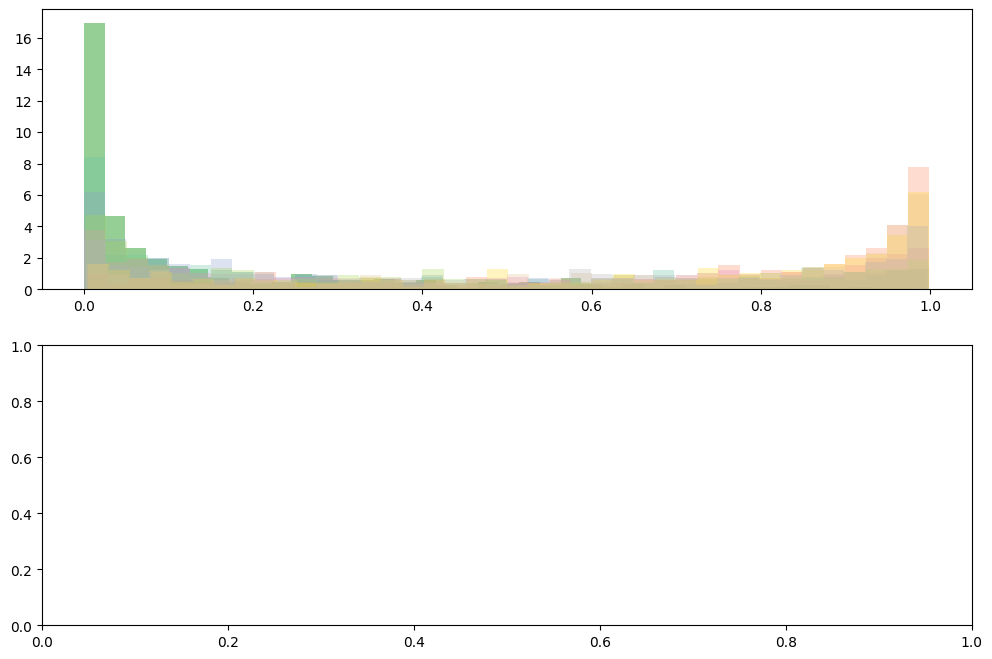

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, (head, T, title) in zip(axes, [
    (head_v1, T_v1, "SDv1.4-only head"),
    (head_mix, T_mix, "Mixed-generator head"),
]):
    # Score the real images
    scores_real = score_with_head(head, T, p_real, c_real)
    ax.hist(scores_real, bins=40, alpha=0.5, label="RAISE-1k (real)", color="tab:green", density=True)

    # Score each fake generator
    colors = plt.cm.Set2(np.linspace(0, 1, len(sb_data)-1))
    for ci, (name, (p, c, y)) in enumerate(sorted(sb_data.items())):
        if "raise" in name.lower(): continue
        scores = score_with_head(head, T, p, c)
        ax.hist(scores, bins=40, alpha=0.3, label=name, color=colors[ci], density=True)

    ax.axvline(0.5, color="red", linestyle="--", alpha=0.5, label="threshold")
    ax.set_xlabel("p(fake)"); ax.set_ylabel("density")
    ax.set_title(title); ax.legend(fontsize=7, ncol=3)

plt.tight_layout()
plt.savefig("/content/m4_histograms.png", dpi=150)
plt.show()

## Summary

The Synthbuster table is the honest evaluation — generators the heads
never trained on, from a completely independent dataset. The key rows:
- **DALL·E 2/3 and Firefly:** genuinely zero-shot for both heads
- **SD 1.4 and GLIDE:** cross-dataset check (same generator, different data)
- **Midjourney v5:** zero-shot for SDv1.4 head, in-distribution for mixed

The transport matrix extends the M1×M2 composite: if p(fake) holds through
the messenger row (where both provenance and watermarks die), the three
modules together cover the full spectrum — evidence fusion proven across
all seven transports.

The histograms show *how* the heads differ: the SDv1.4-only head should
show tight real/fake separation on SD-family generators but overlapping
distributions on DALL·E/Firefly; the mixed head should show better
separation across the board.